In [5]:
!pip install ydata-profiling

In [6]:
import pandas as pd
import numpy as np
from IPython.display import display
from ydata_profiling import ProfileReport

=====================================
## CAMADA BRONZE
=====================================

In [7]:

url = "https://github.com/Nina-Da-Hora/analise-estrategica-marcas-automotivas/releases/download/v1.0/car_prices_dataset.zip"

df_bronze = pd.read_csv(url, compression="zip")

# salvar
df_bronze.to_csv("car_prices_bronze.csv", index=False)

print("Bronze criado com sucesso.")
print("Linhas:", df_bronze.shape[0])
print("Colunas:", df_bronze.shape[1])

Bronze criado com sucesso.
Linhas: 558837
Colunas: 16


======================================
## Análise Exploratória  Dados Brutos
======================================

In [8]:
df = pd.read_csv("car_prices_bronze.csv")
df.head()


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


===============================
## Data Quality Report
===============================

In [9]:
profile = ProfileReport(df_bronze, title="Data Quality Report")
profile.to_file("DQR.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 16/16 [00:36<00:00,  2.28s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

======================================
## Análise de Completude (Nulos)
======================================

In [10]:

total_linhas = len(df)

total_celdas = df.size
total_nulos = df.isna().sum().sum()
porcentaje_nulos = round((total_nulos / total_celdas) * 100, 2)

resumen_dataset = pd.DataFrame({
    "Métrica": ["Total de Registros", "Total de Celdas", "Total de Nulos", "% de Nulos"],
    "Valor": [total_linhas, total_celdas, total_nulos, porcentaje_nulos]
})

display(resumen_dataset)

df_info = pd.DataFrame({
    "Coluna": df.columns,
    "Total Registros": total_linhas,
    "Não Nulos": df.notna().sum().values,
    "Nulos": df.isna().sum().values,
    "% Nulos": (df.isna().sum().values / total_linhas * 100).round(2)
})


df_info = df_info.sort_values("% Nulos", ascending=False)

limite_alerta = 15
df_info["Alerta"] = df_info["% Nulos"].apply(lambda x: "Revisar" if x > limite_alerta else "")

df_info.index = range(1, len(df_info) + 1)

print("-------------------------------------")
print("\n Identificação de nulos por colunas")
display(df_info)


,Métrica,Valor
0,Total de Registros,558837.00
1,Total de Celdas,8941392.00
2,Total de Nulos,123376.00
3,% de Nulos,1.38


-------------------------------------

 Identificação de nulos por colunas


,Coluna,Total Registros,Não Nulos,Nulos,% Nulos,Alerta
1,transmission,558837,493485,65352,11.69,
2,body,558837,545642,13195,2.36,
3,condition,558837,547017,11820,2.12,
4,trim,558837,548186,10651,1.91,
5,model,558837,548438,10399,1.86,
6,make,558837,548536,10301,1.84,
7,color,558837,558088,749,0.13,
8,interior,558837,558088,749,0.13,
9,odometer,558837,558743,94,0.02,
10,mmr,558837,558799,38,0.01,


====================================
## Análise da Estrutura dos Dados
====================================

In [11]:

df_tipos = pd.DataFrame({
    "Coluna": df.columns,
    "Tipo Actual": df.dtypes.values,
    "Valores Únicos": [df[col].nunique(dropna=True) for col in df.columns]
})

# Detectar columnas que parecen tener tipo incorrecto
# Ejemplo: columnas numéricas con pocos valores o object con muchas categorías
df_tipos["Alerta"] = df_tipos.apply(
    lambda row: "Revisar" if (row["Tipo Actual"] == 'object' and row["Valores Únicos"] < 10) else "",
    axis=1
)

# Ajustar índice
df_tipos.index = range(1, len(df_tipos) + 1)

df_tipos

,Coluna,Tipo Actual,Valores Únicos,Alerta
1,year,int64,34,
2,make,object,96,
3,model,object,973,
4,trim,object,1963,
5,body,object,87,
6,transmission,object,4,Revisar
7,vin,object,550297,
8,state,object,64,
9,condition,float64,41,
10,odometer,float64,172278,


====================================
## Análise de duplicados (Unicidade)
====================================


In [12]:

filas_duplicadas = df.duplicated().sum()
df_filas_duplicadas = pd.DataFrame({
"Linhas Totais": [total_linhas],
"Linhas Duplicadas": [filas_duplicadas],
"Linhas Únicas": [total_linhas - filas_duplicadas],
"Percentual Duplicadas (%)": [round(filas_duplicadas / total_linhas * 100, 2)],
"Percentual Únicas (%)": [round((total_linhas - filas_duplicadas) / total_linhas * 100, 2)] })

print("\n Identificação de linhas duplicadas")
display(df_filas_duplicadas)


 Identificação de linhas duplicadas


,Linhas Totais,Linhas Duplicadas,Linhas Únicas,Percentual Duplicadas (%),Percentual Únicas (%)
0,558837,0,558837,0.0,100.0


==========================================
##Análise de Consistência dos Dados
==========================================

In [13]:

df_temp = df.copy()

df_temp["saledate"] = pd.to_datetime(df_temp["saledate"], errors="coerce", utc=True)


df_temp = df_temp.dropna(subset=["saledate"])
df_temp["sale_year"] = df_temp["saledate"].dt.year

  #Venda posterior ou igual ao ano do veículo
ano_inconsistente = df_temp[df_temp["sale_year"] < (df_temp["year"]-1)].shape[0]

  # Preço menor que 0
precio_invalidos = df_temp[df_temp["sellingprice"] <= 0].shape[0]

  #Odômetro não negativo
odometro_invalidos = df_temp[df_temp["odometer"] < 0].shape[0]

  #Preço de venda dentro de um intervalo razoável do MMR
precio_sospechoso = df_temp[
      abs(df_temp["sellingprice"] - df_temp["mmr"]) > df_temp["mmr"] * 2
  ].shape[0]

df_consistencia = pd.DataFrame({
      "Regra de Consistência": [
          "Venda posterior ou igual ao ano do veículo",
          "Preço maior que 0",
          "Odômetro não negativo",
          "Preço de venda dentro de um intervalo razoável do MMR"
      ],
      "Registros inconsistentes": [
          ano_inconsistente,
          precio_invalidos,
          odometro_invalidos,
          precio_sospechoso
      ],
      "Porcentaje (%)": [
          round(ano_inconsistente / total_linhas * 100, 2),
          round(precio_invalidos / total_linhas * 100, 2),
          round(odometro_invalidos / total_linhas * 100, 2),
          round(precio_sospechoso / total_linhas * 100, 2)
      ]
  })
print("-------------------------------------")
print("\n Identificação de inconsistências")
df_consistencia


/tmp/ipykernel_578/4055517355.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_temp["saledate"] = pd.to_datetime(df_temp["saledate"], errors="coerce", utc=True)


-------------------------------------

 Identificação de inconsistências


,Regra de Consistência,Registros inconsistentes,Porcentaje (%)
0,Venda posterior ou igual ao ano do veículo,0,0.00
1,Preço maior que 0,0,0.00
2,Odômetro não negativo,0,0.00
3,Preço de venda dentro de um intervalo razoável...,706,0.13


In [14]:
df['transmission'].unique()

array(['automatic', nan, 'manual', 'Sedan', 'sedan'], dtype=object)

====================================
## Análise de Valores Zerados
====================================

In [15]:

num_cols = df.select_dtypes(include="number")
zeros_num = (num_cols == 0).sum()
df_zeros_num = pd.DataFrame({
    "Coluna": zeros_num.index,
    "Tipo": "Numérica",
    "Qtd_Zeros": zeros_num.values,
    "Percentual (%)": (zeros_num.values / total_linhas * 100).round(2),
    "Alerta": ["Alto % de zeros" if x > 5 else "" for x in (zeros_num / total_linhas * 100)]
})

str_cols = df.select_dtypes(include="object")
zeros_str = (str_cols == "0").sum()
df_zeros_str = pd.DataFrame({
    "Coluna": zeros_str.index,
    "Tipo": "String",
    "Qtd_Zeros": zeros_str.values,
    "Percentual (%)": (zeros_str.values / total_linhas * 100).round(2),
    "Alerta": ["Alto % de zeros" if x > 5 else "" for x in (zeros_str / total_linhas * 100)]
})

df_zeros = pd.concat([df_zeros_num, df_zeros_str])
df_zeros = df_zeros[df_zeros["Qtd_Zeros"] > 0].sort_values("Percentual (%)", ascending=False).reset_index(drop=True)

df_zeros

,Coluna,Tipo,Qtd_Zeros,Percentual (%),Alerta


====================================
## Informações gerais de integridade
====================================

In [16]:
linhas, colunas = df.shape
total_celulas = linhas * colunas
total_nulos = df.isna().sum().sum()
percentual_nulos = round((total_nulos / total_celulas) * 100, 2)
alerta = "Alto % de nulos" if percentual_nulos > 5 else ""

df_integridade_horizontal = pd.DataFrame([{
    "Linhas": linhas,
    "Colunas": colunas,
    "Total de Células": total_celulas,
    "Total de Nulos": total_nulos,
    "Percentual de Nulos (%)": percentual_nulos,
    "Alerta": alerta
}])

df_integridade_horizontal

,Linhas,Colunas,Total de Células,Total de Nulos,Percentual de Nulos (%),Alerta
0,558837,16,8941392,123376,1.38,


========================================================
## Verificação de integridade para colunas numéricas
========================================================

In [17]:

num_cols = df.select_dtypes(include="number").columns

resumo_num = []

for col in num_cols:
    negativos = (df[col] < 0).sum()
    percentual_negativos = round(negativos / total_linhas * 100, 2)
    alerta = "Atenção" if negativos > 0 else ""

    resumo_num.append({
        "Coluna": col,
        "Qtd Negativos": negativos,
        "% Negativos": percentual_negativos,
        "Alerta": alerta
    })

df_resumo_num = pd.DataFrame(resumo_num)
df_resumo_num

,Coluna,Qtd Negativos,% Negativos,Alerta
0,year,0,0.0,
1,condition,0,0.0,
2,odometer,0,0.0,
3,mmr,0,0.0,
4,sellingprice,0,0.0,


========================================================
## Verificação de integridade para colunas categóricas
========================================================

In [18]:

cat_cols = df.select_dtypes(include="object").columns
resumo_cat = []

for col in cat_cols:
    valores_unicos = df[col].nunique(dropna=True)
    alerta = "Revisar" if valores_unicos > 10 else ""

    resumo_cat.append({
        "Coluna": col,
        "Valores Únicos": valores_unicos,
        "Alerta": alerta
    })

df_resumo_cat = pd.DataFrame(resumo_cat)
df_resumo_cat = df_resumo_cat.sort_values("Valores Únicos", ascending=False).reset_index(drop=True)
df_resumo_cat

,Coluna,Valores Únicos,Alerta
0,vin,550297,Revisar
1,seller,14263,Revisar
2,saledate,3766,Revisar
3,trim,1963,Revisar
4,model,973,Revisar
5,make,96,Revisar
6,body,87,Revisar
7,state,64,Revisar
8,color,46,Revisar
9,interior,17,Revisar


========================================================
## Correlação entre todas as colunas numéricas
========================================================

Cada célula mostra o coeficiente de correlação de Pearson entre duas colunas
O valor varia de -1 a 1:

1 → correlação perfeita positiva (quando uma aumenta, a outra aumenta na mesma proporção)

-1 → correlação perfeita negativa (quando uma aumenta, a outra diminui na mesma proporção)

0 → nenhuma correlação linear clar

In [19]:

df.corr(numeric_only=True)

,year,condition,odometer,mmr,sellingprice
year,1.000000,0.340320,-0.772737,0.596631,0.586480
condition,0.340320,1.000000,-0.318188,0.281415,0.321944
odometer,-0.772737,-0.318188,1.000000,-0.588113,-0.582393
mmr,0.596631,0.281415,-0.588113,1.000000,0.983635
sellingprice,0.586480,0.321944,-0.582393,0.983635,1.000000


======================================
## Análise de Consistência Temporal
======================================

In [20]:
ano_min_aceitavel = 1982
ano_max_aceitavel = 2015

anos_min = df["year"].min()
anos_max = df["year"].max()
anos_unicos = df["year"].nunique()

# Crear DataFrame resumido
df_resumo_anos = pd.DataFrame({
    "Métrica": ["Ano mínimo", "Ano máximo", "Total anos únicos"],
    "Valor": [anos_min, anos_max, anos_unicos],
    "Alerta": [
        "Fora de faixa" if anos_min < ano_min_aceitavel or anos_min > ano_max_aceitavel else "",
        "Fora de faixa" if anos_max < ano_min_aceitavel or anos_max > ano_max_aceitavel else "",
        ""
    ]
})

df_resumo_anos

,Métrica,Valor,Alerta
0,Ano mínimo,1982,
1,Ano máximo,2015,
2,Total anos únicos,34,


==================================
## Análise de Valores Atípicos na Coluna de Odômetro
==================================

In [21]:
# Cálculo de outliers usando IQR
Q1 = df['odometer'].quantile(0.25)
Q3 = df['odometer'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['odometer'] < limite_inferior) | (df['odometer'] > limite_superior)]

# Crear resumen como DataFrame
df_outliers_odometer = pd.DataFrame([{
    "Métrica": "Outliers de Odômetro",
    "Qtd Outliers": len(outliers),
    "Percentual (%)": round(len(outliers) / len(df) * 100, 2),
    "Valor Mínimo Outlier": outliers['odometer'].min() if len(outliers) > 0 else None,
    "Valor Máximo Outlier": outliers['odometer'].max() if len(outliers) > 0 else None,
    "Limite Inferior": limite_inferior,
    "Limite Superior": limite_superior
}])

df_outliers_odometer

,Métrica,Qtd Outliers,Percentual (%),Valor Mínimo Outlier,Valor Máximo Outlier,Limite Inferior,Limite Superior
0,Outliers de Odômetro,10375,1.86,205220.0,999999.0,-77736.0,205216.0


=====================================================
## Análise Específica – sellingprice - Nulos e Zeros
=====================================================

In [22]:

nulos = df["sellingprice"].isna().sum()
zeros = (df["sellingprice"] == 0).sum()
df_sellingprice_qualidade = pd.DataFrame({
     "Métrica": ["Nulos", "Zeros", "Total Problemáticos"],
     "Quantidade": [nulos, zeros, nulos + zeros],
     "Percentual (%)": [ round(nulos/total_linhas*100, 2),
                        round(zeros/total_linhas*100, 2),
                         round((nulos+zeros)/total_linhas*100, 2) ] })

df_sellingprice_qualidade

,Métrica,Quantidade,Percentual (%)
0,Nulos,12,0.0
1,Zeros,0,0.0
2,Total Problemáticos,12,0.0


================================================
## Análise Específica – sellingprice - Outliers
================================================

In [23]:

precos = df["sellingprice"].dropna()

Q1 = precos.quantile(0.25)
Q3 = precos.quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers = precos[precos > limite_superior]

df_outliers_sellingprice = pd.DataFrame([{
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR,
    "Limite Superior": limite_superior,
    "Qtd Outliers": len(outliers),
    "Percentual Outliers (%)": round(len(outliers)/len(df)*100, 2)
}])

df_outliers_sellingprice

,Q1,Q3,IQR,Limite Superior,Qtd Outliers,Percentual Outliers (%)
0,6900.0,18200.0,11300.0,35150.0,16354,2.93


======================================
## Resumo estatístico do sellingprice
======================================

In [24]:

resumo = df["sellingprice"].describe()

df_resumo = pd.DataFrame(resumo).reset_index()
df_resumo.columns = ["Métrica", "Valor"]
df_resumo["Valor"] = df_resumo["Valor"].apply(lambda x: f"${x:,.2f}")

df_resumo

,Métrica,Valor
0,count,"$558,825.00"
1,mean,"$13,611.36"
2,std,"$9,749.50"
3,min,$1.00
4,25%,"$6,900.00"
5,50%,"$12,100.00"
6,75%,"$18,200.00"
7,max,"$230,000.00"


=========================
## CAMADA SILVER
=========================

In [25]:

dfsilver = df_bronze.copy()

In [26]:
# Selecionar colunas necessárias
df_silver = dfsilver[[
"vin",
"year",
"make",
"model",
"body",
"state",
"condition",
"odometer",
"mmr",
"sellingprice",
"saledate"
]]

#Renomear colunas
df_silver = df_silver.rename(columns={
"vin": "chassi",
"year":"ano",
"make":"marca",
"model":"modelo",
"body": "carroceria",
"state":"estado",
"condition":"condicao",
"odometer":"odometro",
"mmr":"preco_mmr",
"sellingprice":"preco_venda",
"saledate":"data_venda"
})

In [27]:
df_silver.head()

,chassi,ano,marca,modelo,carroceria,estado,condicao,odometro,preco_mmr,preco_venda,data_venda
0,5xyktca69fg566472,2015,Kia,Sorento,SUV,ca,5.0,16639.0,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,5xyktca69fg561319,2015,Kia,Sorento,SUV,ca,5.0,9393.0,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,wba3c1c51ek116351,2014,BMW,3 Series,Sedan,ca,45.0,1331.0,31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,yv1612tb4f1310987,2015,Volvo,S60,Sedan,ca,41.0,14282.0,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,wba6b2c57ed129731,2014,BMW,6 Series Gran Coupe,Sedan,ca,43.0,2641.0,66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


==================
# Coluna Chassi
==================


In [28]:
def limpar_vin(df, coluna_chassi='chassi'):

    total_inicial = df.shape[0]
    vin_invalidos = df[df[coluna_chassi].str.len() != 17].shape[0]

    df[coluna_chassi] = df[coluna_chassi].astype(str).str.strip().str.upper()

    df = df[df[coluna_chassi].str.len() == 17].copy()

    total_final = df.shape[0]

    resumo_vin = pd.DataFrame([{
        "VIN inválidos eliminados": vin_invalidos,
        "Registros restantes": total_final,
        "% VIN inválidos": round(vin_invalidos / total_inicial * 100, 2),
    }])

    return df, resumo_vin

In [29]:

df_silver, resumo_vin = limpar_vin(df_silver, 'chassi')

display(resumo_vin)

,VIN inválidos eliminados,Registros restantes,% VIN inválidos
0,26,558811,0.0


====================
# Coluna Ano
====================


In [30]:
def limpar_ano(df, ano_col='ano', ano_min=1982, ano_max=2015):

    df = df.copy()

    df[ano_col] = pd.to_numeric(df[ano_col], errors='coerce')

    df = df[(df[ano_col] >= ano_min) & (df[ano_col] <= ano_max)].copy()

    return df


In [31]:
ano_min = 1982
ano_max = 2015

df_silver["ano"] = pd.to_numeric(df_silver["ano"], errors='coerce')

fuera_rango = df_silver[(df_silver['ano'].isna()) | (df_silver['ano'] < ano_min) | (df_silver['ano'] > ano_max)]

if fuera_rango.empty:
    todos_los_anos = pd.DataFrame({'Ano': list(range(ano_min, ano_max + 1))})

    ventas_por_ano = df_silver['ano'].value_counts().rename('Quantidade de Vendas').reset_index()
    ventas_por_ano.columns = ['Ano', 'Quantidade de Vendas']

    reporte = pd.merge(todos_los_anos, ventas_por_ano, on='Ano', how='left').fillna(0)

    reporte['Quantidade de Vendas'] = reporte['Quantidade de Vendas'].astype(int)

    mensaje = pd.DataFrame({'Ano': [''], 'Quantidade de Vendas': ['Não há anos fora do intervalo']})
    reporte = pd.concat([reporte, mensaje], ignore_index=True)

    display(reporte)
else:
    fuera_rango_mensaje = fuera_rango.copy()
    fuera_rango_mensaje['Mensagem'] = 'Ano fora do intervalo'
    display(fuera_rango_mensaje)

,Ano,Quantidade de Vendas
0,1982,2
1,1983,1
2,1984,5
3,1985,10
4,1986,11
5,1987,8
6,1988,11
7,1989,20
8,1990,49
9,1991,67


=========================
# Coluna marca
=========================


In [32]:
df_silver['marca'].nunique()

96

In [33]:
marca_unicos = df_silver['marca'].unique()
print(marca_unicos)

['Kia' 'BMW' 'Volvo' 'Nissan' 'Chevrolet' 'Audi' 'Ford' 'Hyundai' 'Buick'
 'Cadillac' 'Acura' 'Lexus' 'Infiniti' 'Jeep' 'Mercedes-Benz' 'Mitsubishi'
 'Mazda' 'MINI' 'Land Rover' 'Lincoln' 'lincoln' 'Jaguar' 'Volkswagen'
 'Toyota' 'Subaru' 'Scion' 'Porsche' nan 'bmw' 'Dodge' 'FIAT' 'Chrysler'
 'ford' 'Ferrari' 'Honda' 'GMC' 'mitsubishi' 'Ram' 'smart' 'chevrolet'
 'Bentley' 'chrysler' 'pontiac' 'Pontiac' 'Saturn' 'Maserati' 'Mercury'
 'HUMMER' 'landrover' 'cadillac' 'land rover' 'mercedes' 'mazda' 'toyota'
 'lexus' 'gmc truck' 'honda' 'nissan' 'porsche' 'Saab' 'Suzuki' 'dodge'
 'subaru' 'Oldsmobile' 'oldsmobile' 'hyundai' 'jeep' 'Isuzu' 'dodge tk'
 'Geo' 'acura' 'volkswagen' 'suzuki' 'kia' 'audi' 'Rolls-Royce' 'gmc'
 'maserati' 'mazda tk' 'mercury' 'buick' 'hyundai tk' 'mercedes-b' 'vw'
 'Daewoo' 'chev truck' 'ford tk' 'plymouth' 'Plymouth' 'ford truck'
 'Tesla' 'airstream' 'dot' 'Aston Martin' 'Fisker' 'Lamborghini' 'Lotus']


In [34]:
def tratamento_marcas(df, col_coluna='marca'):

    df = df.copy()

    # Eliminar nulos da coluna
    df = df.dropna(subset=[col_coluna])

    # Tratamento inicial: espaços e minúsculas
    df[col_coluna] = df[col_coluna].astype(str).str.strip().str.lower()

    # Correções diretas
    correcoes_diretas = {
        'landrover': 'land rover',
        'vw': 'volkswagen',
        'mercedes-b': 'mercedes-benz',
        'mercedes': 'mercedes-benz',
        'chev truck': 'chevrolet',
        'chev': 'chevrolet',
        'chevy': 'chevrolet',
        'infinit': 'infiniti'
    }
    df[col_coluna] = df[col_coluna].replace(correcoes_diretas)

    # Remoção de sufixos genéricos
    sufixos_remover = [r'\s+tk$', r'\s+truck$', r'\s+motor$', r'\s+motors$', r'\s+corp$', r'\s+inc$']
    for pattern in sufixos_remover:
        df[col_coluna] = df[col_coluna].str.replace(pattern, '', regex=True)

    # Padronização de capitalização
    df[col_coluna] = df[col_coluna].str.title()

    return df

In [35]:

df_silver = tratamento_marcas(df_silver, 'marca')

# Criar DataFrame de resumo
resumo_modelos = pd.DataFrame({
    "Antes_da_limpeza": [df_bronze['make'].nunique()],
    "Depois_da_limpeza": [df_silver['marca'].nunique()]
})

display(resumo_modelos)

,Antes_da_limpeza,Depois_da_limpeza
0,96,55


==================
# Coluna Modelo
==================





In [36]:
df_silver["modelo"].unique()

array(['Sorento', '3 Series', 'S60', '6 Series Gran Coupe', 'Altima',
       'M5', 'Cruze', 'A4', 'Camaro', 'A6', 'Optima', 'Fusion', 'Sonata',
       'Q5', '6 Series', 'Impala', '5 Series', 'A3', 'XC70', 'X5', 'SQ5',
       'S5', 'Verano', 'Suburban', 'ELR', 'V60', 'X6', 'ILX', 'K900',
       'Malibu', 'RX 350', 'Versa', 'Elantra', 'Versa Note', 'A8', 'X1',
       nan, 'Enclave', 'TTS', '4 Series', 'Silverado 2500HD', 'MDX',
       'Silverado 1500', 'SRX', 'G Coupe', 'G Sedan', 'FX', 'Santa Fe',
       'Genesis', 'Equus', 'Sonata Hybrid', 'Accent', 'Veloster',
       'Elantra Coupe', 'Azera', 'Tucson', 'Genesis Coupe', 'Wrangler',
       'S-Class', 'GS 350', 'Outlander', 'C-Class', 'Mazda2', 'Rio', 'M',
       '370Z', 'Soul', 'Outlander Sport', 'SLK-Class', 'ES 350',
       'E-Class', 'Mazda3', 'Cooper Clubman', 'Cooper', 'CX-9', 'Forte',
       'Compass', 'JX', 'RX 450h', 'LR4', 'Mazda5', 'Range Rover Evoque',
       'LS 460', 'GLK-Class', 'Sportage', 'Grand Cherokee', 'MKX', 'mkt',


In [37]:

def limpar_modelo(df):

    df = df.dropna(subset=['modelo']).copy()
    df['modelo'] = df['modelo'].str.strip().str.title()

    # Limpezas específicas: modelo coincide com carroceria
    df.loc[(df['modelo'] == 'G Sedan') & (df['carroceria'] == 'Sedan'), 'modelo'] = 'G'
    df.loc[(df['modelo'] == 'G Coupe') & (df['carroceria'] == 'Coupe'), 'modelo'] = 'G'
    df.loc[(df['modelo'] == 'G Convertible') & (df['carroceria'] == 'Convertible'), 'modelo'] = 'G'
    df.loc[(df['modelo'] == 'G37 Convertible') & (df['carroceria'] == 'Convertible'), 'modelo'] = 'G37'
    df.loc[(df['modelo'] == 'G37 Coupe') & (df['carroceria'] == 'Coupe'), 'modelo'] = 'G37'
    df.loc[(df['modelo'] == 'Granturismo Convertible') & (df['carroceria'] == 'Convertible'), 'modelo'] = 'Granturismo'
    df.loc[(df['modelo'] == 'Genesis Coupe') & (df['carroceria'] == 'Coupe'), 'modelo'] = 'Genesis'

    # Substituições frequentes
    alteracoes = {
        'Rx350': 'RX350',
        'Sclass': 'S-Class',
        'Mazdaspeed3': 'Mazdaspeed 3',
        'Mountnr': 'Mountaineer',
        'Twn/Cntry': 'Town & Country',
        'Twn&Country': 'Town & Country',
        'Town And Country': 'Town & Country',
        'Subrbn': 'Suburban',
        'Expeditn': 'Expedition',
        'Ridgelin': 'Ridgeline',
        'Siera': 'Sierra',
        'Es 350': 'ES 350'
    }
    df['modelo'] = df['modelo'].replace(alteracoes)

    return df

In [38]:

df_silver = limpar_modelo(df_silver)

# Criar DataFrame de resumo
resumo_modelo = pd.DataFrame({
    "Antes_da_limpeza": [df_bronze['model'].nunique()],
    "Depois_da_limpeza": [df_silver['modelo'].nunique()]
})
display(resumo_modelo)

,Antes_da_limpeza,Depois_da_limpeza
0,973,844


======================
# Coluna carroceria
======================


In [39]:
df_silver["carroceria"].unique()

array(['SUV', 'Sedan', 'Convertible', 'Coupe', 'Wagon', 'Hatchback',
       'Crew Cab', 'G Coupe', 'G Sedan', 'Elantra Coupe', 'Genesis Coupe',
       'Minivan', nan, 'Van', 'Double Cab', 'CrewMax Cab', 'Access Cab',
       'King Cab', 'SuperCrew', 'CTS Coupe', 'Extended Cab',
       'E-Series Van', 'SuperCab', 'Regular Cab', 'G Convertible', 'Koup',
       'Quad Cab', 'CTS-V Coupe', 'sedan', 'G37 Convertible', 'Club Cab',
       'Xtracab', 'Q60 Convertible', 'CTS Wagon', 'convertible',
       'G37 Coupe', 'Mega Cab', 'Cab Plus 4', 'Q60 Coupe', 'Cab Plus',
       'Beetle Convertible', 'TSX Sport Wagon', 'Promaster Cargo Van',
       'GranTurismo Convertible', 'CTS-V Wagon', 'Ram Van', 'minivan',
       'suv', 'Transit Van', 'van', 'regular-cab', 'g sedan', 'g coupe',
       'hatchback', 'king cab', 'supercrew', 'g convertible', 'coupe',
       'crew cab', 'wagon', 'double cab', 'e-series van', 'regular cab',
       'quad cab', 'g37 convertible', 'supercab', 'extended cab',
       'crew

In [40]:

def limpar_carroceria(df, coluna="carroceria"):

    df = df.copy()

     # Eliminar nulos
    df = df[df["carroceria"].notna()]

   # Limpar espaços e capitalização
    df["carroceria"] = df["carroceria"].str.strip().str.title()

    # Mapeamento de normalização
    map_carroceria = {
        "Sedan": "Sedan", "G Sedan": "Sedan",
        "Suv": "SUV", "SUV": "SUV",
        "Hatchback": "Hatchback",
        "Coupe": "Coupe", "G Coupe": "Coupe", "Genesis Coupe": "Coupe", "Elantra Coupe": "Coupe",
        "Cts Coupe": "Coupe", "Cts-V Coupe": "Coupe", "Q60 Coupe": "Coupe", "G37 Coupe": "Coupe", "Koup": "Coupe",
        "Convertible": "Convertible", "G Convertible": "Convertible", "G37 Convertible": "Convertible",
        "Q60 Convertible": "Convertible", "Beetle Convertible": "Convertible", "Granturismo Convertible": "Convertible",
        "Wagon": "Wagon", "Cts Wagon": "Wagon", "Cts-V Wagon": "Wagon", "Tsx Sport Wagon": "Wagon",
        "Minivan": "Minivan",
        "Van": "Van", "E-Series Van": "Van", "Ram Van": "Van", "Transit Van": "Van", "Promaster Cargo Van": "Van",
        "Ram Van B250": "Van", "Ram Van B350": "Van",
        "Crew Cab": "Cab", "Supercrew": "Cab", "Supercab": "Cab", "Regular Cab": "Cab",
        "Extended Cab": "Cab", "Quad Cab": "Cab", "Double Cab": "Cab", "Crewmax Cab": "Cab",
        "King Cab": "Cab", "Club Cab": "Cab", "Cab Plus": "Cab", "Cab Plus 4": "Cab",
        "Xtracab": "Cab", "Access Cab": "Cab", "Mega Cab": "Cab", "Regular-Cab": "Cab"
    }

    df["carroceria"] = df["carroceria"].map(map_carroceria).fillna(df["carroceria"])

    return df

In [41]:

df_silver = limpar_carroceria(df_silver)

# Resumo antes e depois da limpeza
resumo_carroceria = pd.DataFrame({
    "Antes_da_limpeza": [df_bronze['body'].nunique()],
    "Depois_da_limpeza": [df_silver['carroceria'].nunique()]
})
display(resumo_carroceria)

,Antes_da_limpeza,Depois_da_limpeza
0,87,9


==================
# Coluna estado
==================

Padronização da Coluna Estado e Criação da Coluna Região


In [42]:
estados_2letras = df_bronze[df_bronze["state"].str.len() == 2]["state"].unique()

print(estados_2letras)

['ca' 'tx' 'pa' 'mn' 'az' 'wi' 'tn' 'md' 'fl' 'ne' 'nj' 'nv' 'oh' 'mi'
 'ga' 'va' 'sc' 'nc' 'in' 'il' 'co' 'ut' 'mo' 'ny' 'ma' 'pr' 'or' 'la'
 'wa' 'hi' 'qc' 'ab' 'on' 'ok' 'ms' 'nm' 'al' 'ns']


In [43]:

def limpar_estados(df):
    estados_usa = [
        'ca','tx','pa','mn','az','wi','tn','md','fl','ne','nj','nv','oh','mi',
        'ga','va','sc','nc','in','il','co','ut','mo','ny','ma','or','la',
        'wa','hi','ok','ms','nm','al'
    ]

    df = df[df["estado"].str.lower().isin(estados_usa)].copy()
    df["estado"] = df["estado"].str.strip().str.upper()

    regioes = {
        'CA':'West','TX':'South','PA':'North','MN':'Midwest','AZ':'West',
        'WI':'North','TN':'South','MD':'South','FL':'South','NE':'Midwest',
        'NJ':'North','NV':'West','OH':'North','MI':'North','GA':'South',
        'VA':'South','SC':'South','NC':'South','IN':'Midwest','IL':'Midwest',
        'CO':'Midwest','UT':'West','MO':'Midwest','NY':'North',
        'MA':'North','OR':'West','LA':'South','WA':'West','HI':'West',
        'OK':'Midwest','MS':'South','NM':'West','AL':'South'
    }

    df["region"] = df["estado"].map(regioes)

    return df

In [44]:

df_silver = limpar_estados(df_silver)

# Resumo
resumo_estados = pd.DataFrame({
    "Métrica": [
        "Total de registros",
        "Total de colunas",
        "Estados únicos",
        "Regiones únicas",
        "Regiones nulas"
    ],
    "Valor": [
        len(df_silver),
        df_silver.shape[1],
        df_silver["estado"].nunique(),
        df_silver["region"].nunique(),
        df_silver["region"].isna().sum()
    ]
})

display(resumo_estados)

,Métrica,Valor
0,Total de registros,538065
1,Total de colunas,12
2,Estados únicos,33
3,Regiones únicas,4
4,Regiones nulas,0


====================
# Coluna condicao
====================


In [45]:
df_silver["condicao"].describe()

,condicao
count,527027.000000
mean,30.788094
std,13.350049
min,1.000000
25%,24.000000
50%,35.000000
75%,42.000000
max,49.000000


In [46]:
df_silver["condicao"].value_counts().sort_index()

,count
condicao,
1.0,6848
2.0,19372
3.0,10170
4.0,19485
5.0,10636
11.0,86
12.0,94
13.0,79
14.0,126


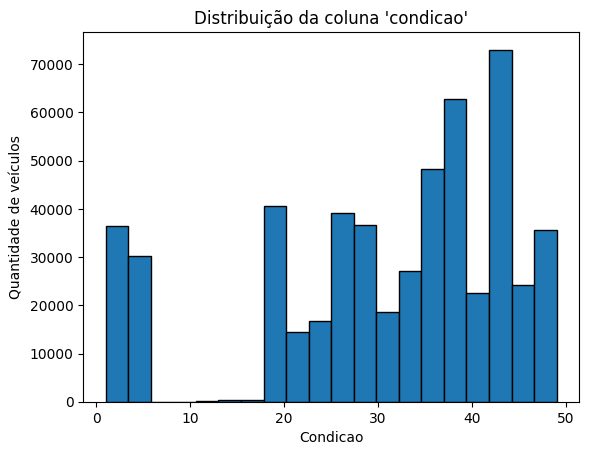

In [47]:
import matplotlib.pyplot as plt

plt.hist(df_silver["condicao"], bins=20, edgecolor='black')
plt.title("Distribuição da coluna 'condicao'")
plt.xlabel("Condicao")
plt.ylabel("Quantidade de veículos")
plt.show()

In [48]:
labels_condicao = []

def classificar_condicao(df, coluna_condicao="condicao", labels=None):
    df = df.copy()
    if labels is None:
        labels = ["Muito ruim", "Ruim", "Regular", "Boa", "Excelente"]

    # Calcular percentiles
    percentis = df[coluna_condicao].quantile([0, 0.2, 0.4, 0.6, 0.8, 1])

    # Crear columna categórica
    df["condicao_categoria"] = pd.cut(
        df[coluna_condicao],
        bins=percentis,
        labels=labels,
        include_lowest=True
    )

    return df

In [49]:
df_silver = classificar_condicao(df_silver, coluna_condicao="condicao")

conteo = df_silver["condicao_categoria"].value_counts().sort_index()


porcentaje = (conteo / conteo.sum() * 100).round(2)


resumen_condicao = pd.DataFrame({
    "Condicao": conteo.index,
    "Cantidad": conteo.values,
    "Porcentaje (%)": porcentaje.values
})

display(resumen_condicao)


,Condicao,Cantidad,Porcentaje (%)
0,Muito ruim,107959,20.48
1,Ruim,106939,20.29
2,Regular,119090,22.60
3,Boa,108237,20.54
4,Excelente,84802,16.09


In [50]:
df_silver.groupby("condicao")["preco_venda"].mean()

,preco_venda
condicao,
1.0,4101.324912
2.0,5888.258466
3.0,12589.296588
4.0,17771.205491
5.0,24707.363012
11.0,4547.558140
12.0,3857.180851
13.0,3353.164557
14.0,3316.666667


=====================
# Coluna odometro
=====================


In [51]:
def limpar_odometro(df):
    df = df.copy()
    df = df[df['odometro'].notna()]
    df = df[df['odometro'] >= 0]
    return df

In [52]:

df_silver = limpar_odometro(df_silver)

total_inicial = len(df_silver)
total_final = len(df_silver)

eliminados = total_inicial - total_final

resumen_odometro = pd.DataFrame({
    "Métrica": ["Registros iniciales", "Registros eliminados", "Registros finales"],
    "Cantidad": [total_inicial, eliminados, total_final],
    "Porcentaje (%)": [
        100,
        round(eliminados / total_inicial * 100, 2),
        round(total_final / total_inicial * 100, 2)
    ]
})

display(resumen_odometro)

,Métrica,Cantidad,Porcentaje (%)
0,Registros iniciales,537984,100.0
1,Registros eliminados,0,0.0
2,Registros finales,537984,100.0


=====================
# Coluna preco_mmr
=====================


In [53]:
def limpar_preco_mmr(df, coluna_preco="preco_mmr"):

    df = df.copy()

    # Eliminar registros nulos
    df = df[df[coluna_preco].notna()]

    # Eliminar precios negativos
    df = df[df[coluna_preco] >= 0]

    return df

In [54]:
df_silver["diferenca_preco"] = df_silver["preco_venda"] - df_silver["preco_mmr"]

In [55]:
# Total inicial
total_inicial = df_silver.shape[0]

# Llamar a la función que elimina nulos
df_silver = limpar_preco_mmr(df_silver, 'preco_mmr')

# Total final después de eliminar nulos
total_final = df_silver.shape[0]

# Crear DataFrame resumen
df_eliminados = pd.DataFrame({
    "Métrica": [
        "Registros iniciales",
        "Registros eliminados por preco_mmr nulo",
        "Registros finales"
    ],
    "Cantidad": [
        total_inicial,
        total_inicial - total_final,
        total_final
    ]
})

display(df_eliminados)

,Métrica,Cantidad
0,Registros iniciales,537984
1,Registros eliminados por preco_mmr nulo,12
2,Registros finales,537972


In [56]:
print("--------------------------------")
print("Resumen estadístico de preco_mmr")
print("--------------------------------")

resumo = df_silver["preco_mmr"].describe().round(2)
display(resumo)

--------------------------------
Resumen estadístico de preco_mmr
--------------------------------


,preco_mmr
count,537972.00
mean,13881.41
std,9631.55
min,25.00
25%,7350.00
50%,12400.00
75%,18400.00
max,182000.00


In [57]:
# Percentiles e IQR

Q1 = df_silver["preco_mmr"].quantile(0.25)
Q3 = df_silver["preco_mmr"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar outliers
outliers_df = df_silver[(df_silver["preco_mmr"] < limite_inferior) |
                        (df_silver["preco_mmr"] > limite_superior)].copy()

# Resumo de outliers
resumen_outliers = pd.DataFrame({
    "Métrica": ["Limite inferior", "Limite superior", "Cantidad de outliers"],
    "Valor": [limite_inferior, limite_superior, len(outliers_df)]
})


display(resumen_outliers)


,Métrica,Valor
0,Limite inferior,-9225.0
1,Limite superior,34975.0
2,Cantidad de outliers,15923.0


In [58]:
marca_preco = df_silver.groupby("marca")["preco_mmr"].agg(
    unidades="count",
    preco_promedio="mean",
    preco_mediana="median",
    preco_min="min",
    preco_max="max"
).sort_values(by="preco_promedio")


marca_preco_format = marca_preco.copy()


for col in ["preco_promedio", "preco_mediana", "preco_min", "preco_max"]:
    marca_preco_format[col] = marca_preco_format[col].apply(lambda x: f"${x:,.2f}")


display(marca_preco_format)

,unidades,preco_promedio,preco_mediana,preco_min,preco_max
marca,,,,,
Daewoo,2,$487.50,$487.50,$475.00,$500.00
Geo,19,$609.21,$575.00,$275.00,$950.00
Oldsmobile,364,"$1,095.05","$1,050.00",$25.00,"$3,225.00"
Isuzu,200,"$1,754.50","$1,425.00",$300.00,"$6,475.00"
Suzuki,899,"$3,471.58","$2,850.00",$225.00,"$15,150.00"
Saturn,2831,"$3,516.10","$2,850.00",$25.00,"$13,700.00"
Saab,483,"$3,753.26","$3,125.00",$25.00,"$14,950.00"
Pontiac,4434,"$3,967.82","$3,650.00",$50.00,"$30,600.00"
Mercury,1985,"$4,108.77","$3,450.00",$50.00,"$16,500.00"


=======================
# Coluna preco_venda
======================


In [59]:
def limpar_preco_venda(df, coluna_preco="preco_venda"):

    df = df.copy()
    total_inicial = len(df)

    df = df[df[coluna_preco].notna()]

    df = df[df[coluna_preco] > 0]

    return df

In [60]:
df_silver = limpar_preco_venda(df_silver, 'preco_venda')

In [61]:

df_silver["preco_venda"].describe()

,preco_venda
count,537972.000000
mean,13722.529951
std,9701.567178
min,1.000000
25%,7100.000000
50%,12250.000000
75%,18300.000000
max,230000.000000


In [62]:

df_silver["preco_venda"].sort_values().head(10)

,preco_venda
348252,1.0
48453,1.0
293223,1.0
423599,100.0
502080,100.0
449497,100.0
384512,100.0
466143,100.0
196184,100.0
409841,100.0


In [63]:
resumen_precio = pd.DataFrame({
    "Indicador": [
        "Total de registros",
        "Precios menores a $100",
        "Porcentaje de precios < $100"
    ],
    "Valor": [
        len(df_silver),
        (df_silver["preco_venda"] < 100).sum(),
        round(((df_silver["preco_venda"] < 100).sum() / len(df_silver)) * 100, 2)
    ]
})

# Convertir columna a string
resumen_precio["Valor"] = resumen_precio["Valor"].astype(str)

# Agregar símbolo %
resumen_precio.loc[2, "Valor"] = resumen_precio.loc[2, "Valor"] + " %"

resumen_precio

,Indicador,Valor
0,Total de registros,537972.0
1,Precios menores a $100,3.0
2,Porcentaje de precios < $100,0.0 %


In [64]:
df_silver["preco_venda"].median()

12250.0

=====================
# Coluna data_venda
=====================


In [65]:
df_silver["data_venda"].describe()

,data_venda
count,537972
unique,3697
top,Tue Feb 10 2015 01:30:00 GMT-0800 (PST)
freq,5233


In [66]:
def limpar_data_venda(df, coluna_data="data_venda"):
    df = df.copy()


    df[coluna_data] = pd.to_datetime(df[coluna_data], errors='coerce', utc=True)

    # Eliminar registros nulos o inválidos
    df = df[df[coluna_data].notna()].copy()

    # Ahora sí, crear columnas de año y mes
    df["ano_venda"] = df[coluna_data].dt.year
    df["mes_venda"] = df[coluna_data].dt.month

    return df

In [67]:
limpar_data_venda(df_silver)

/tmp/ipykernel_578/287785818.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[coluna_data] = pd.to_datetime(df[coluna_data], errors='coerce', utc=True)


,chassi,ano,marca,modelo,carroceria,estado,condicao,odometro,preco_mmr,preco_venda,data_venda,region,condicao_categoria,diferenca_preco,ano_venda,mes_venda
0,5XYKTCA69FG566472,2015,Kia,Sorento,SUV,CA,5.0,16639.0,20500.0,21500.0,2014-12-16 04:30:00+00:00,West,Muito ruim,1000.0,2014,12
1,5XYKTCA69FG561319,2015,Kia,Sorento,SUV,CA,5.0,9393.0,20800.0,21500.0,2014-12-16 04:30:00+00:00,West,Muito ruim,700.0,2014,12
2,WBA3C1C51EK116351,2014,Bmw,3 Series,Sedan,CA,45.0,1331.0,31900.0,30000.0,2015-01-14 20:30:00+00:00,West,Excelente,-1900.0,2015,1
3,YV1612TB4F1310987,2015,Volvo,S60,Sedan,CA,41.0,14282.0,27500.0,27750.0,2015-01-28 20:30:00+00:00,West,Boa,250.0,2015,1
4,WBA6B2C57ED129731,2014,Bmw,6 Series Gran Coupe,Sedan,CA,43.0,2641.0,66000.0,67000.0,2014-12-18 04:30:00+00:00,West,Boa,1000.0,2014,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,KNALW4D4XF6019304,2015,Kia,K900,Sedan,IN,45.0,18255.0,35300.0,33000.0,2015-07-09 00:00:00+00:00,Midwest,Excelente,-2300.0,2015,7
558833,3C6TD5ET6CG112407,2012,Ram,2500,Cab,WA,5.0,54393.0,30200.0,30800.0,2015-07-08 02:30:00+00:00,West,Muito ruim,600.0,2015,7
558834,5UXZW0C58CL668465,2012,Bmw,X5,SUV,CA,48.0,50561.0,29800.0,34000.0,2015-07-08 02:30:00+00:00,West,Excelente,4200.0,2015,7
558835,1N4AL3AP0FC216050,2015,Nissan,Altima,Sedan,GA,38.0,16658.0,15100.0,11100.0,2015-07-08 23:45:00+00:00,South,Boa,-4000.0,2015,7


In [68]:

total_linhas = len(df_silver)

df_info = pd.DataFrame({
    "Coluna": df_silver.columns,
    "Não Nulos": df_silver.notna().sum().values,
    "Nulos": df_silver.isna().sum().values,
    "% Nulos": (df_silver.isna().sum().values / total_linhas * 100).round(2)
})

df_info.index = range(1, len(df_info) + 1)

df_info

,Coluna,Não Nulos,Nulos,% Nulos
1,chassi,537972,0,0.00
2,ano,537972,0,0.00
3,marca,537972,0,0.00
4,modelo,537972,0,0.00
5,carroceria,537972,0,0.00
6,estado,537972,0,0.00
7,condicao,526992,10980,2.04
8,odometro,537972,0,0.00
9,preco_mmr,537972,0,0.00
10,preco_venda,537972,0,0.00


In [69]:
print(df_silver.shape)

(537972, 14)


=================================
## Comparação de Modelos
=================================

In [70]:
# =================================
# Ranking de Vendas por Modelo
# =================================

ranking_modelos_bajas = (
    df_silver
    .groupby(['marca', 'modelo'], as_index=False)
    ['preco_venda']
    .sum()
    .rename(columns={'preco_venda': 'Total_Ventas'})
)

ranking_modelos_bajas = ranking_modelos_bajas.sort_values(by='Total_Ventas', ascending=True).reset_index(drop=True)

print("=================================")
print("Ranking de Vendas por Modelo:")
print("=================================")
ranking_modelos_bajas.head(10)

Ranking de Vendas por Modelo:


,marca,modelo,Total_Ventas
0,Toyota,Paseo,150.0
1,Oldsmobile,Regency,300.0
2,Dodge,Spirit,300.0
3,Cadillac,Fleetwood,350.0
4,Chevrolet,Corsica,350.0
5,Geo,Metro,400.0
6,Honda,Civic Del Sol,450.0
7,Oldsmobile,Achieva,500.0
8,Audi,Cabriolet,800.0
9,Daewoo,Nubira,900.0


In [71]:
# =================================
# Receita Total por Modelos
# =================================

receita_modelos = (
    df_silver
    .groupby('modelo', as_index=False)['preco_venda']
    .sum()
    .rename(columns={'preco_venda': 'Receita_Total'})
    .sort_values(by='Receita_Total', ascending=False)
    .reset_index(drop=True)
)

print("=================================")
print("Receita Total por Modelos:")
print("================================")
receita_modelos.head(10)

Receita Total por Modelos:


,modelo,Receita_Total
0,F-150,266629809.0
1,Altima,220715708.0
2,Escape,162652002.0
3,Fusion,158728820.0
4,G Sedan,147918806.0
5,Camry,139752558.0
6,Explorer,139189094.0
7,3 Series,135302080.0
8,Edge,107663357.0
9,Silverado 1500,106872546.0


In [72]:
# =================================
# Preço médio de Vendas
# =================================

# Agrupar por modelo y calcular el precio promedio
preco_medio_modelos = (
    df_silver
    .groupby('modelo', as_index=False)['preco_venda']
    .mean()
    .rename(columns={'preco_venda': 'Preco_Medio'})
    .sort_values(by='Preco_Medio', ascending=False)  # ordenar de mayor a menor precio
    .reset_index(drop=True)
)

# Mostrar top 10 modelos con mayor precio promedio
preco_medio_modelos.head(10)

,modelo,Preco_Medio
0,458 Italia,183000.000000
1,Sls Amg Gt,156500.000000
2,I8,154222.222222
3,Flying Spur,154000.000000
4,Ghost,153488.235294
5,California,131846.153846
6,Sls Amg,116016.666667
7,Gallardo,112625.000000
8,Continental Gtc Speed,111000.000000
9,F430,109750.000000


=================================
## Análise Regional
=================================

In [73]:
# =================================
# Análisi Regional
# =================================

pd.options.display.float_format = '{:,.0f}'.format


vendas_por_estado = (
    df_silver
    .groupby('estado', as_index=False)['preco_venda']
    .sum()
    .rename(columns={'preco_venda': 'Total_Vendas'})
    .sort_values(by='Total_Vendas', ascending=False)
    .reset_index(drop=True)
)

print ("=================================")
print ("Vendas por Estado:")
print ("=================================")
vendas_por_estado

Vendas por Estado:


,estado,Total_Vendas
0,FL,"1,136,868,813"
1,CA,"1,037,106,213"
2,PA,"851,449,049"
3,TX,"599,203,861"
4,GA,"440,991,661"
5,NJ,"371,676,844"
6,TN,"352,911,483"
7,IL,"343,615,326"
8,OH,"304,437,934"
9,MO,"229,427,961"


In [74]:
# =================================
# Ranking de modelos por estado
# =================================

ranking_modelos_estado = (
    df_silver
    .groupby(['estado','modelo'], as_index=False)['preco_venda']
    .sum()
    .rename(columns={'preco_venda': 'Total_Vendas'})
    .sort_values(['estado','Total_Vendas'], ascending=[True, False])
    .reset_index(drop=True)
)

print ("=================================")
print ("Ranking de modelos por estado")
print ("=================================")

ranking_modelos_estado.head(20)

Ranking de modelos por estado


,estado,modelo,Total_Vendas
0,AL,G Sedan,"36,300"
1,AL,Tundra,"28,700"
2,AL,Cruze,"22,800"
3,AL,F-150,"19,000"
4,AL,Maxima,"18,200"
5,AL,Challenger,"17,800"
6,AL,Durango,"17,800"
7,AL,Explorer Sport Trac,"13,700"
8,AL,Lacrosse,"12,700"
9,AL,Expedition,"11,400"


In [75]:
# =================================
# Comparação de preço médio entre estados
# =================================

preco_medio_estado = (
    df_silver
    .groupby('estado', as_index=False)['preco_venda']
    .mean()
    .rename(columns={'preco_venda': 'Preco_Medio'})
    .sort_values(by='Preco_Medio', ascending=False)
)


print ("=================================")
print ("Comparação de preço médio entre estados")
print ("=================================")

preco_medio_estado

Comparação de preço médio entre estados


,estado,Preco_Medio
27,TN,"17,093"
25,PA,"16,050"
3,CO,"16,006"
20,NV,"15,199"
12,MI,"15,020"
7,IL,"14,891"
14,MO,"14,585"
2,CA,"14,583"
22,OH,"14,411"
31,WA,"14,153"


=======================
# Pipeline
=======================


In [76]:
def pipeline_limpieza(df, mostrar_resumen=True):

    df_silver = df.copy()

    df_silver = df_silver[[
        "vin",
        "year",
        "make",
        "model",
        "body",
        "state",
        "condition",
        "odometer",
        "mmr",
        "sellingprice",
        "saledate"
    ]].rename(columns={
        "vin": "chassi",
        "year":"ano",
        "make":"marca",
        "model":"modelo",
        "body": "carroceria",
        "state":"estado",
        "condition":"condicao",
        "odometer":"odometro",
        "mmr":"preco_mmr",
        "sellingprice":"preco_venda",
        "saledate":"data_venda"
    })
    if mostrar_resumen:
        print("...Colunas selecionadas e renomeadas...")

    # VIN
    df_silver, _ = limpar_vin(df_silver, coluna_chassi='chassi') # Correctly unpack the tuple
    if mostrar_resumen:
        print("...Chassi limpo...Registros restantes.. ", len(df_silver))

    # Ano
    df_silver = limpar_ano(df_silver, ano_col='ano', ano_min=1982, ano_max=2015)
    if mostrar_resumen:
        print("...Anos filtrados. Registros restantes... ", len(df_silver))

    # Marcas
    df_silver = tratamento_marcas(df_silver, col_coluna='marca') # Changed 'coluna' to 'col_coluna' to match function signature
    if mostrar_resumen:
        print("...Marcas normalizadas...")

    # Carroceria
    df_silver = limpar_carroceria(df_silver, coluna='carroceria')
    if mostrar_resumen:
        print("...Carroceria normalizada... Categorias...", df_silver["carroceria"].nunique())

    # Modelos
    df_silver = limpar_modelo(df_silver)
    if mostrar_resumen:
        print("...Modelos normalizados... Modelos únicos...")

    # Estados
    df_silver = limpar_estados(df_silver)
    if mostrar_resumen:
        print("...Estados filtrados e regiões adicionadas... Estados únicos...", df_silver["estado"].nunique())

    # Condición
    df_silver = classificar_condicao(df_silver, coluna_condicao='condicao')
    if mostrar_resumen:
        print("...Condição classificada. Quantidade por categoria...")
        display(df_silver['condicao_categoria'].value_counts())

    # Odómetro
    df_silver = limpar_odometro(df_silver)
    if mostrar_resumen:
        print("...Odômetro limpo. Registros restantes...", len(df_silver))

    # Precio de venta
    df_silver = limpar_preco_venda(df_silver, coluna_preco='preco_venda')
    if mostrar_resumen:
        print("...Preço de venda limpo. Registros restantes...", len(df_silver))

    # Fecha de venta
    df_silver = limpar_data_venda(df_silver, coluna_data='data_venda')
    if mostrar_resumen:
        print("...Data de venda limpa e colunas ano/mês criadas...")

    return df_silver

df_silver = pipeline_limpieza(df_bronze, mostrar_resumen=True)

...Colunas selecionadas e renomeadas...
...Chassi limpo...Registros restantes..  558811
...Anos filtrados. Registros restantes...  558811
...Marcas normalizadas...
...Carroceria normalizada... Categorias... 9
...Modelos normalizados... Modelos únicos...
...Estados filtrados e regiões adicionadas... Estados únicos... 33
...Condição classificada. Quantidade por categoria...


,count
condicao_categoria,
Regular,119090
Boa,108237
Muito ruim,107959
Ruim,106939
Excelente,84802


...Odômetro limpo. Registros restantes... 537984
...Preço de venda limpo. Registros restantes... 537972


/tmp/ipykernel_578/287785818.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[coluna_data] = pd.to_datetime(df[coluna_data], errors='coerce', utc=True)


...Data de venda limpa e colunas ano/mês criadas...


================================
#Crear Camada Silver
================================


In [77]:
# Guardar como CSV
df_silver.to_csv("car_prices_silver.csv", index=False)

In [78]:
df_silver.dtypes

,0
chassi,object
ano,int64
marca,object
modelo,object
carroceria,object
estado,object
condicao,float64
odometro,float64
preco_mmr,float64
preco_venda,float64


In [79]:
df_silver.head()

,chassi,ano,marca,modelo,carroceria,estado,condicao,odometro,preco_mmr,preco_venda,data_venda,region,condicao_categoria,ano_venda,mes_venda
0,5XYKTCA69FG566472,2015,Kia,Sorento,SUV,CA,5,"16,639","20,500","21,500",2014-12-16 04:30:00+00:00,West,Muito ruim,2014,12
1,5XYKTCA69FG561319,2015,Kia,Sorento,SUV,CA,5,"9,393","20,800","21,500",2014-12-16 04:30:00+00:00,West,Muito ruim,2014,12
2,WBA3C1C51EK116351,2014,Bmw,3 Series,Sedan,CA,45,"1,331","31,900","30,000",2015-01-14 20:30:00+00:00,West,Excelente,2015,1
3,YV1612TB4F1310987,2015,Volvo,S60,Sedan,CA,41,"14,282","27,500","27,750",2015-01-28 20:30:00+00:00,West,Boa,2015,1
4,WBA6B2C57ED129731,2014,Bmw,6 Series Gran Coupe,Sedan,CA,43,"2,641","66,000","67,000",2014-12-18 04:30:00+00:00,West,Boa,2014,12


In [80]:
df_silver.columns


Index(['chassi', 'ano', 'marca', 'modelo', 'carroceria', 'estado', 'condicao',
       'odometro', 'preco_mmr', 'preco_venda', 'data_venda', 'region',
       'condicao_categoria', 'ano_venda', 'mes_venda'],
      dtype='object')

================================
# Camada Gold
================================



In [81]:
df_gold = df_silver.copy()

In [82]:
total_preco_venda = df_gold['preco_venda'].sum()
print(total_preco_venda)

7382336883.0


In [83]:

df_gold.to_csv("car_prices_gold.csv", index=False)

resumen_kpis = pd.DataFrame({
    "Indicador": ["Total de vendas", "Receita total", "Preço médio"],
    "Valor": [len(df_gold), df_gold['preco_venda'].sum(), df_gold['preco_venda'].mean()]
})

resumen_kpis["Valor"] = resumen_kpis["Valor"].apply(lambda x: "${:,.2f}".format(x) if isinstance(x, (int,float)) else x)
resumen_kpis.to_csv("gold_kpis_gerais.csv", index=False)

vendas_ano = df_gold.groupby('ano_venda')['preco_venda'].count().reset_index()
vendas_ano.rename(columns={'preco_venda': 'vendas_acumuladas'}, inplace=True)
vendas_ano.to_csv("gold_vendas_ano.csv", index=False)

vendas_modelo = df_gold.groupby('modelo').agg(
    total_vendas=('preco_venda', 'count'),
    receita_total=('preco_venda', 'sum'),
    preco_medio=('preco_venda', 'mean')
).reset_index()

vendas_modelo["receita_total"] = vendas_modelo["receita_total"].map("${:,.2f}".format)
vendas_modelo["preco_medio"] = vendas_modelo["preco_medio"].map("${:,.2f}".format)
vendas_modelo.to_csv("gold_vendas_modelo.csv", index=False)


vendas_mes = df_gold.groupby(['ano_venda', 'mes_venda']).agg(
    total_vendas=('preco_venda', 'count'),
    receita_total=('preco_venda', 'sum')
).reset_index()

vendas_mes["receita_total"] = vendas_mes["receita_total"].map("${:,.2f}".format)
vendas_mes.to_csv("gold_vendas_mes.csv", index=False)

vendas_estado = df_gold.groupby('estado').agg(
    total_vendas=('preco_venda', 'count'),
    receita_total=('preco_venda', 'sum'),
    preco_medio=('preco_venda', 'mean')
).reset_index()

vendas_estado["receita_total"] = vendas_estado["receita_total"].map("${:,.2f}".format)
vendas_estado["preco_medio"] = vendas_estado["preco_medio"].map("${:,.2f}".format)
vendas_estado.to_csv("gold_vendas_estado.csv", index=False)

preco_medio_marca = df_gold.groupby("marca")["preco_venda"].agg(
    total_vendas="count",
    preco_medio="mean"
).sort_values("total_vendas", ascending=False).reset_index()

preco_medio_marca["preco_medio"] = preco_medio_marca["preco_medio"].map("${:,.2f}".format)
preco_medio_marca.to_csv("gold_preco_medio_marca.csv", index=False)

receita_marca = df_gold.groupby("marca")["preco_venda"].agg(
    total_vendas="count",
    receita_total="sum",
    preco_medio="mean"
).sort_values("receita_total", ascending=False).reset_index()

receita_marca["receita_total"] = receita_marca["receita_total"].map("${:,.2f}".format)
receita_marca["preco_medio"] = receita_marca["preco_medio"].map("${:,.2f}".format)
receita_marca.to_csv("gold_receita_marca.csv", index=False)

baixa_performance = receita_marca.sort_values("total_vendas").head(10)
baixa_performance.to_csv("gold_baixa_performance.csv", index=False)

df_gold["faixa_quilometragem"] = pd.cut(
    df_gold["odometro"],
    bins=[0, 50000, 100000, 150000, 200000, 300000],
    labels=["0-50k", "50k-100k", "100k-150k", "150k-200k", "200k+"]
)
preco_km = df_gold.groupby("faixa_quilometragem", observed=False).agg(
    preco_medio_venda=("preco_venda", "mean"),
    total_vendas=("preco_venda", "count")
).reset_index()

preco_km["preco_medio_venda"] = preco_km["preco_medio_venda"].map("${:,.2f}".format)
preco_km.to_csv("gold_preco_por_quilometragem.csv", index=False)

df_gold["diferenca_preco"] = df_gold["preco_venda"] - df_gold["preco_mmr"]

total_registros_val = df_gold["diferenca_preco"].count()
vendas_abaixo_mmr_val = (df_gold["diferenca_preco"] < 0).sum()

percentual_mmr = pd.DataFrame({
    "total_registros": [total_registros_val],
    "vendas_abaixo_mmr": [vendas_abaixo_mmr_val]
})

percentual_mmr["percentual_abaixo_mmr"] = (
    percentual_mmr["vendas_abaixo_mmr"] / percentual_mmr["total_registros"] * 100
).round(2)

percentual_mmr.to_csv("gold_percentual_vendas_abaixo_mmr.csv", index=False)

vendas_ytd = df_gold.groupby(['ano_venda','mes_venda']).agg(
    vendas_mes=('preco_venda','count'),
    receita_mes=('preco_venda','sum')
).reset_index()

vendas_ytd["vendas_ytd"] = vendas_ytd.groupby("ano_venda")["vendas_mes"].cumsum()
vendas_ytd["receita_ytd"] = vendas_ytd.groupby("ano_venda")["receita_mes"].cumsum()

vendas_ytd.to_csv("gold_vendas_ytd.csv", index=False)

print("...Todos os arquivos Gold foram salvos corretamente...")


...Todos os arquivos Gold foram salvos corretamente...


==================================
##CARREGAMENTO DO BANCO
==================================

In [84]:
from sqlalchemy import create_engine


In [85]:
engine = create_engine('sqlite:///car_prices_final.db')
df_bronze.to_sql('car_prices_bronze', con=engine, if_exists='replace', index=False)
df_silver.to_sql('car_prices_silver', con=engine, if_exists='replace', index=False)
df_gold.to_sql('car_prices_gold', con=engine, if_exists='replace', index=False)

537972

##
